# Описание проекта<br>
Позади много уроков и заданий, и закрепить свои знания, как обычно, вы сможете в самостоятельном проекте. Это непростой проект, в котором от вас потребуется больше самостоятельности. Этапы работы описаны кратко, и вам понадобится декомпозировать задачи, то есть разделить их на более мелкие. Опирайтесь на знания об этапах анализа данных и машинного обучения из прошлых курсов.
Перейдём к задаче. HR-аналитики компании «Работа с заботой» помогают бизнесу оптимизировать управление персоналом: бизнес предоставляет данные, а аналитики предлагают, как избежать финансовых потерь и оттока сотрудников. В этом HR-аналитикам пригодится машинное обучение, с помощью которого получится быстрее и точнее отвечать на вопросы бизнеса.<br>
Компания предоставила данные с характеристиками сотрудников компании. Среди них — уровень удовлетворённости сотрудника работой в компании. Эту информацию получили из форм обратной связи: сотрудники заполняют тест-опросник, и по его результатам рассчитывается доля их удовлетворённости от 0 до 1, где 0 — совершенно неудовлетворён, 1 — полностью удовлетворён. 
Собирать данные такими опросниками не так легко: компания большая, и всех сотрудников надо сначала оповестить об опросе, а затем проследить, что все его прошли. <br>
У вас будет несколько задач. Первая — построить модель, которая сможет предсказать уровень удовлетворённости сотрудника на основе данных заказчика. <br>
Почему бизнесу это важно: удовлетворённость работой напрямую влияет на отток сотрудников. А предсказание оттока — одна из важнейших задач HR-аналитиков. Внезапные увольнения несут в себе риски для компании, особенно если уходит важный сотрудник.
Ваша вторая задача — построить модель, которая сможет на основе данных заказчика предсказать то, что сотрудник уволится из компании.<br>
Теперь расскажем подробнее о задачах. <br><br>
Задача 1: предсказание уровня удовлетворённости сотрудника<br>
Для этой задачи заказчик предоставил данные с признаками:
* id — уникальный идентификатор сотрудника;
* dept — отдел, в котором работает сотрудник;
* level — уровень занимаемой должности;
* workload — уровень загруженности сотрудника;
* employment_years — длительность работы в компании (в годах);
* last_year_promo — показывает, было ли повышение за последний год;
* last_year_violations — показывает, нарушал ли сотрудник трудовой договор за последний год;
* supervisor_evaluation — оценка качества работы сотрудника, которую дал руководитель;
* salary — ежемесячная зарплата сотрудника;
* job_satisfaction_rate — уровень удовлетворённости сотрудника работой в компании, целевой признак.

In [1]:
!pip install phik -q

In [2]:
!pip install -Uq scikit-learn 

In [3]:

import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
import math
import numpy as np
import phik
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.preprocessing import (
    OneHotEncoder, 
    StandardScaler, 
    OrdinalEncoder, 
    MinMaxScaler, 
    LabelEncoder
)
from sklearn.metrics import make_scorer, roc_auc_score

from sklearn.model_selection import RandomizedSearchCV, GridSearchCV

In [4]:
RANDOM_STATE = 42

## Загрузка данных

In [5]:
data_train = pd.read_csv('/datasets/train_job_satisfaction_rate.csv')

In [6]:
X_test = pd.read_csv('/datasets/test_features.csv')

In [7]:
y_test = pd.read_csv('/datasets/test_target_job_satisfaction_rate.csv')

In [8]:
data_train.head(10)

,id,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,job_satisfaction_rate
0,155278,sales,junior,medium,2,no,no,1,24000,0.58
1,653870,hr,junior,high,2,no,no,5,38400,0.76
2,184592,sales,junior,low,1,no,no,2,12000,0.11
3,171431,technology,junior,low,4,no,no,2,18000,0.37
4,693419,hr,junior,medium,1,no,no,3,22800,0.20
5,405448,hr,middle,low,7,no,no,4,30000,0.78
6,857135,sales,sinior,medium,9,no,no,3,56400,0.56
7,400657,purchasing,middle,high,9,no,no,3,52800,0.44
8,198846,hr,junior,low,1,no,no,2,13200,0.14
9,149797,technology,middle,high,6,no,no,3,54000,0.47


In [9]:
data_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     4000 non-null   int64  
 1   dept                   3994 non-null   object 
 2   level                  3996 non-null   object 
 3   workload               4000 non-null   object 
 4   employment_years       4000 non-null   int64  
 5   last_year_promo        4000 non-null   object 
 6   last_year_violations   4000 non-null   object 
 7   supervisor_evaluation  4000 non-null   int64  
 8   salary                 4000 non-null   int64  
 9   job_satisfaction_rate  4000 non-null   float64
dtypes: float64(1), int64(4), object(5)
memory usage: 312.6+ KB


In [10]:
data_train.describe()

,id,employment_years,supervisor_evaluation,salary,job_satisfaction_rate
count,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000
mean,544957.621000,3.718500,3.476500,33926.700000,0.533995
std,257883.104622,2.542513,1.008812,14900.703838,0.225327
min,100954.000000,1.000000,1.000000,12000.000000,0.030000
25%,322836.750000,2.000000,3.000000,22800.000000,0.360000
50%,534082.500000,3.000000,4.000000,30000.000000,0.560000
75%,771446.000000,6.000000,4.000000,43200.000000,0.710000
max,999521.000000,10.000000,5.000000,98400.000000,1.000000


In [11]:
X_test.head(10)

,id,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary
0,485046,marketing,junior,medium,2,no,no,5,28800
1,686555,hr,junior,medium,1,no,no,4,30000
2,467458,sales,middle,low,5,no,no,4,19200
3,418655,sales,middle,low,6,no,no,4,19200
4,789145,hr,middle,medium,5,no,no,5,40800
5,429973,purchasing,middle,medium,6,no,no,3,42000
6,850699,technology,junior,medium,3,no,no,3,26400
7,500791,sales,middle,high,9,no,no,4,49200
8,767867,marketing,middle,high,3,no,yes,4,62400
9,937235,sales,junior,medium,1,no,yes,3,26400


In [12]:
X_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   id                     2000 non-null   int64 
 1   dept                   1998 non-null   object
 2   level                  1999 non-null   object
 3   workload               2000 non-null   object
 4   employment_years       2000 non-null   int64 
 5   last_year_promo        2000 non-null   object
 6   last_year_violations   2000 non-null   object
 7   supervisor_evaluation  2000 non-null   int64 
 8   salary                 2000 non-null   int64 
dtypes: int64(4), object(5)
memory usage: 140.8+ KB


In [13]:
X_test.describe()

,id,employment_years,supervisor_evaluation,salary
count,2000.000000,2000.000000,2000.000000,2000.000000
mean,552765.213500,3.666500,3.526500,34066.800000
std,253851.326129,2.537222,0.996892,15398.436729
min,100298.000000,1.000000,1.000000,12000.000000
25%,339052.000000,1.000000,3.000000,22800.000000
50%,550793.000000,3.000000,4.000000,30000.000000
75%,765763.750000,6.000000,4.000000,43200.000000
max,999029.000000,10.000000,5.000000,96000.000000


In [14]:
y_test.head(10)

,id,job_satisfaction_rate
0,130604,0.74
1,825977,0.75
2,418490,0.60
3,555320,0.72
4,826430,0.08
5,817219,0.76
6,269033,0.64
7,962356,0.38
8,649052,0.14
9,532834,0.59


In [15]:
y_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 2 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     2000 non-null   int64  
 1   job_satisfaction_rate  2000 non-null   float64
dtypes: float64(1), int64(1)
memory usage: 31.4 KB


In [16]:
y_test.describe()

,id,job_satisfaction_rate
count,2000.000000,2000.00000
mean,552765.213500,0.54878
std,253851.326129,0.22011
min,100298.000000,0.03000
25%,339052.000000,0.38000
50%,550793.000000,0.58000
75%,765763.750000,0.72000
max,999029.000000,1.00000


имеются пропуски в таблицах data_train и X_test, и там и там в столбцах level и dept. Заполним пропуски в пайплайнах. <br>
Типы данных в столбцах в норме, переделывать не нужно.<br>
Названия столбцов соотвествуют данным и записаны в "змеином" регистре.

## Предобработка данных


**Проверка дубликатов**

In [17]:
data_train.duplicated().sum()

0

In [18]:
X_test.duplicated().sum()

0

In [19]:
y_test.duplicated().sum()

0

В столбце level заметил опечатку, вместо senior записано sinior, исправим


In [20]:
data_train['level'] = data_train['level'].str.replace('sinior', 'senior')
X_test['level'] = X_test['level'].str.replace('sinior', 'senior')

Явных дубликатов не обнаружено. Заполнение пропусков проведем в пайплайне

## Исследовательский анализ данных

**Исследуем количественные признаки**

In [21]:
# создадим функции для постороения графиков. разделим фуннкции для графиков дискретных и непрерывных величин

def disсrete(df, column):
    plt.figure(figsize=(15,5))
    plt.subplot(1, 2, 1)
    plt.title(f'Гистограмма "{column}"')
    sns.countplot(x=df[column], palette="cividis")
    plt.xlabel(f'Значения "{column}"')
    plt.ylabel('Частота')
    
    plt.subplot(1, 2, 2)
    plt.xlabel(f'Значения "{column}"')
    plt.title(f'Диаграмма размаха для "{column}"')
    sns.boxplot(x=df[column], color='skyblue')
    

def continuous(df, column):
    plt.figure(figsize=(15, 4))
    plt.subplot(1, 2, 1)
    plt.xlabel(f'Значения "{column}"')
    plt.ylabel('Частота')
    plt.title(f'Гистограмма для "{column}"')
    sns.histplot(df[column], color='#484554')
    
    plt.subplot(1, 2, 2)
    plt.xlabel(f'Значения "{column}"')
    plt.title(f'Диаграмма размаха для "{column}"')
    sns.boxplot(x=df[column], color='skyblue')

In [22]:
num_col_1 = ['employment_years', 'supervisor_evaluation'] #дискретные количественные признаки
num_col_2 = ['salary', 'job_satisfaction_rate'] #непрерывные количественные признаки

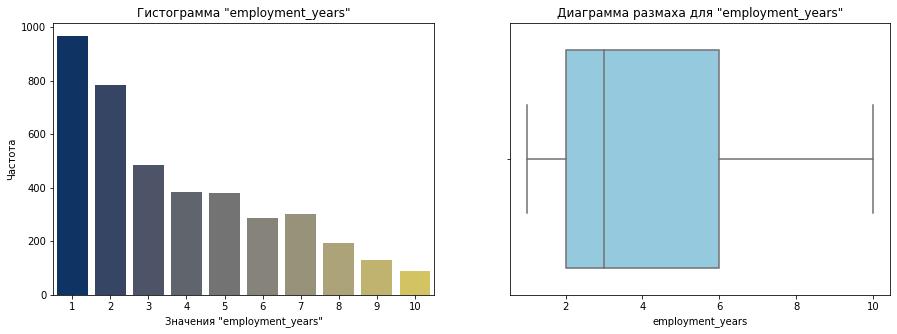

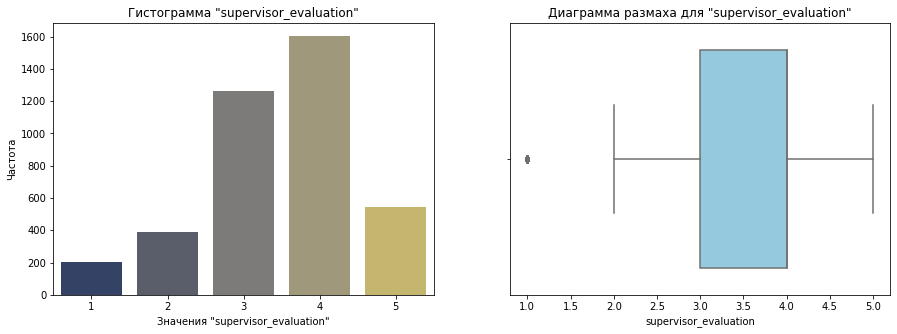

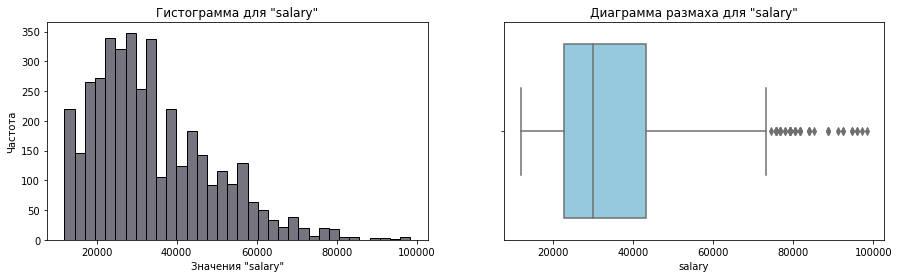

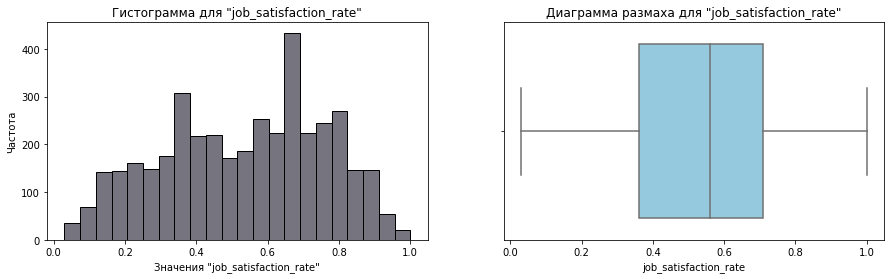

In [23]:
for column in num_col_1:
    disсrete(data_train, column)
    
for column in num_col_2:
    continuous(data_train, column)

**Анализ X_test**

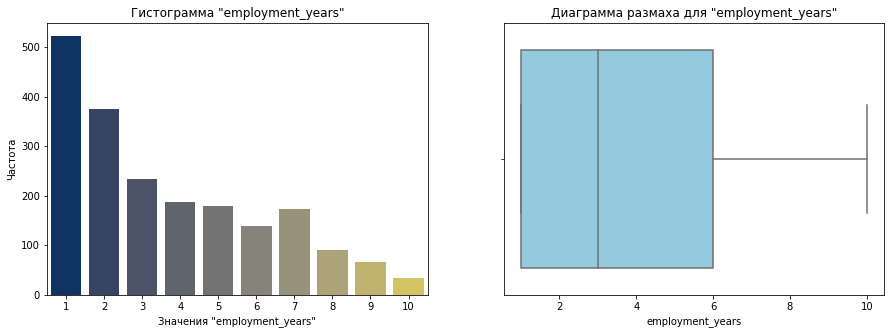

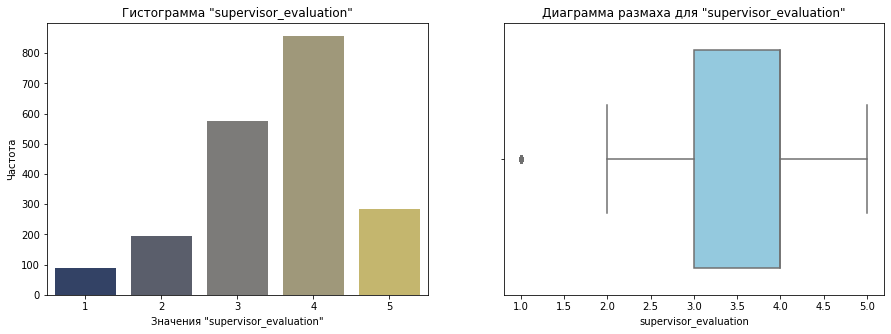

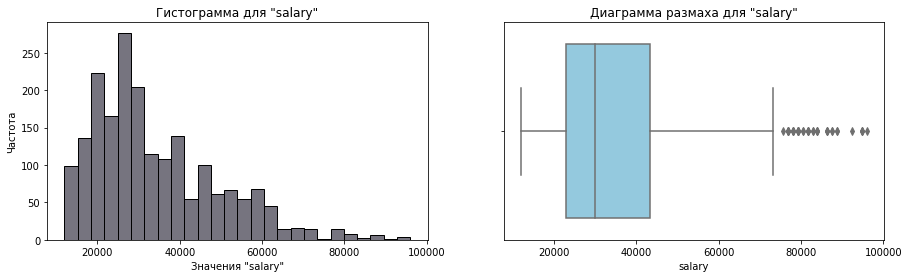

In [24]:
for column in num_col_1:
    disсrete(X_test, column)
    
continuous(X_test, 'salary')

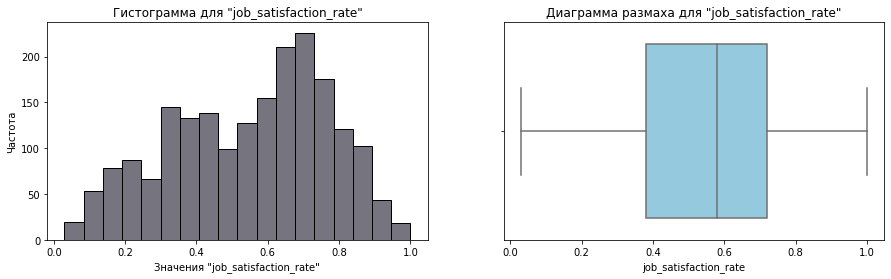

In [25]:
continuous(y_test, 'job_satisfaction_rate')

Категориальные признаки в датасетах

In [26]:
def cat_graph(df, column, name):
    plt.figure(figsize=(5,5))
    plt.title(f'Круговая диагнрамма для "{column}"')
    plt.pie(x=df.groupby(column)[name].count(),
            startangle=90,
            labeldistance=1.1, 
            wedgeprops={'linewidth':3, 'edgecolor':'white'}, 
            autopct='%1.1f%%',
            labels=df.groupby(column)[name].count().index, 
            colors=sns.color_palette('cividis'))

In [27]:
cat_col = ['dept', 
           'level', 
           'workload', 
           'last_year_promo', 
           'last_year_violations']


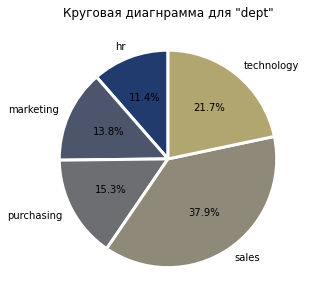

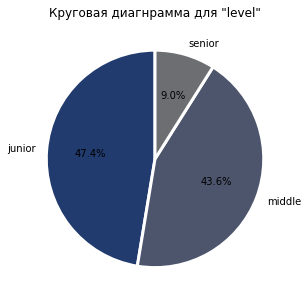

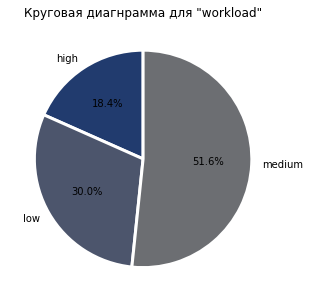

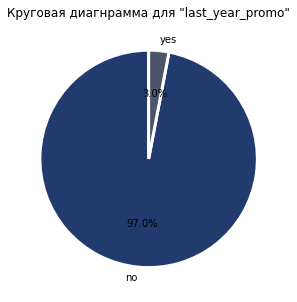

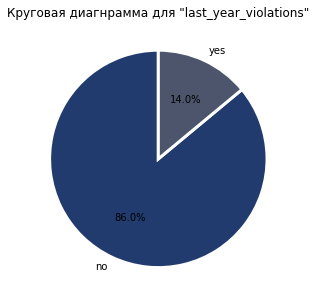

In [28]:

for column in cat_col:
    cat_graph(data_train, column, 'id')
    

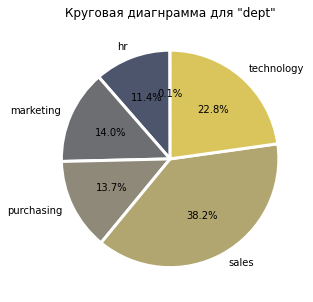

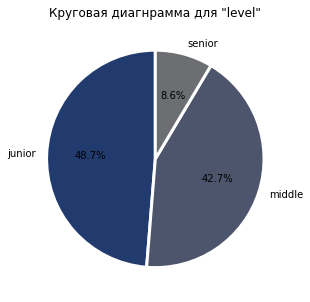

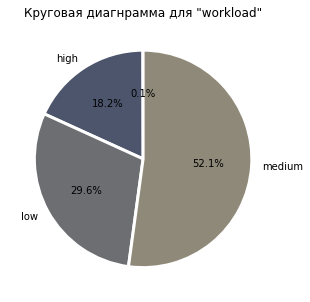

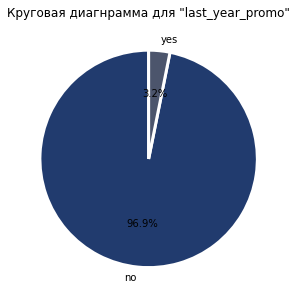

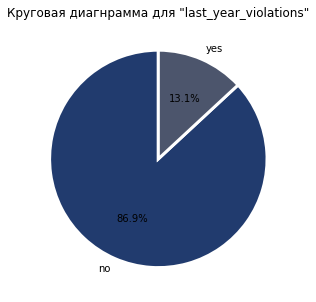

In [29]:
for column in cat_col:
    cat_graph(X_test, column, 'id')

есть какие-то пустые значения в столбцах workload и dept, заменим их пропусками, обработаем потом в пайплайне

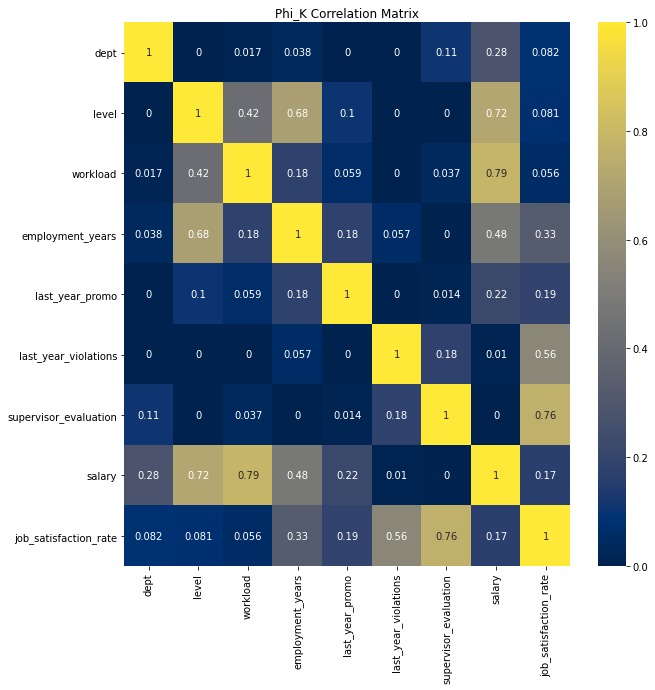

In [30]:
corr_matrix = data_train.drop(['id'], axis=1).phik_matrix(interval_cols=num_col_2)


#визуализация матрицы корреляции 
plt.figure(figsize=(10, 10))
sns.heatmap(corr_matrix, annot=True, cmap='cividis')
plt.title('Phi_K Correlation Matrix')
plt.show()

Мультиколлинеарности не наблюдается, сильнее всего целевой признак коррелирует с нарушениями трудового договора и оценкой качества работы руководителем. 

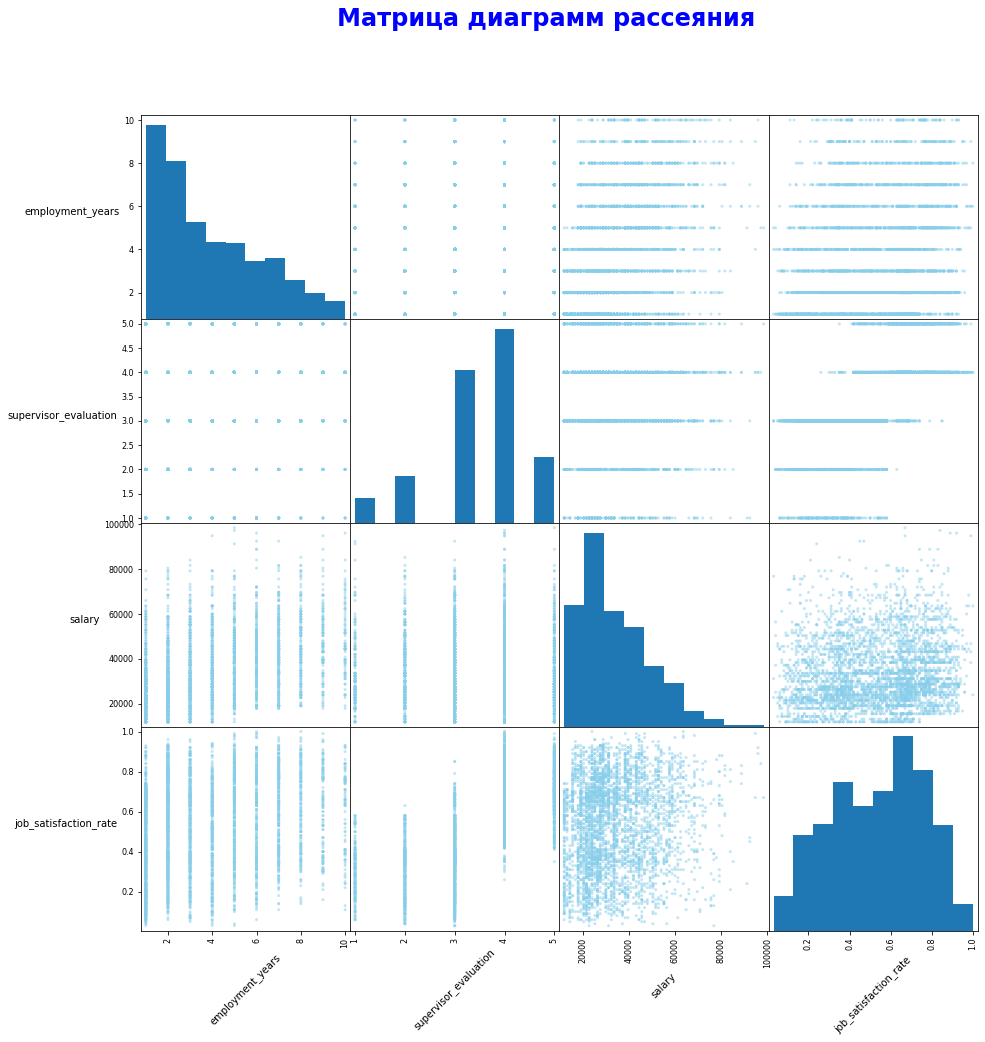

In [31]:
axes = pd.plotting.scatter_matrix(data_train[data_train.columns[data_train.columns != 'id']], figsize=(15, 15), color='skyblue')

for ax in axes.flatten():
    ax.xaxis.label.set_rotation(45)
    ax.yaxis.label.set_rotation(0)
    ax.yaxis.label.set_ha('right')
plt.suptitle('Матрица диаграмм рассеяния', fontsize=24, fontweight="bold", color='blue')
plt.show()

## Подготовка данных

По данным имеем следующее: <br> <br>

* Три признака:
dept, last_year_promo, last_year_violations — нужно кодировать с помощью OneHotEncoder.
* Два признака: level, workload — нужно кодировать с помощью OrdinalEncoder.
* Количественных 3 признака:
employment_years, supervisor_evaluation, salary - нужно масштабировать.
* В признаках пропуски встречаются и обработаем их в пайплайне.
* Целевой признак — job_satisfaction_rate. Задачу мультиклассовой классификации тут рассматривать не будем.

In [32]:

X_test = X_test.sort_values(by='id').set_index('id')
X_test.head()

,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary
id,,,,,,,,
100298,hr,junior,low,2,no,no,4,19200
100480,marketing,junior,low,4,no,no,4,16800
100503,purchasing,middle,high,5,no,no,4,55200
100610,sales,middle,medium,5,no,no,4,43200
100692,sales,middle,high,6,no,no,4,48000


In [33]:

y_test = y_test.sort_values(by='id').set_index('id')
y_test.head()

,job_satisfaction_rate
id,
100298,0.80
100480,0.84
100503,0.79
100610,0.75
100692,0.69


In [34]:
# уберем во всех данных id в индекс
data_train.set_index('id', inplace=True)


Конечно, если мы убираем id, велика вероятность появления явных дубликатов, однако, я считаю, что удалять их нельзя, ведь это реальные работники с уникальными id, и даже если это смещает предсказания модели, то обоснованно.

## Обучение моделей

In [35]:
# Составим списки категорий
ohe_col = ['dept', 'last_year_promo', 'last_year_violations']
ord_col = ['level', 'workload']
num_col = ['salary', 'employment_years', 'supervisor_evaluation']


In [36]:
X_train = data_train.drop('job_satisfaction_rate', axis=1)
y_train = data_train['job_satisfaction_rate']

In [37]:
ohe_pipe = Pipeline(
    [
        ('simple_imputer_ohe_1', SimpleImputer(missing_values=np.nan, strategy='most_frequent')),
#         ('simple_imputer_ohe_2', SimpleImputer(missing_values=' ', strategy='most_frequent')),
        ('ohe', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False))
    ]
)

In [38]:
ord_pipe = Pipeline(
    [
        (
            'simple_imputer_ord_before',
            SimpleImputer(missing_values=np.nan, strategy='most_frequent')
        ),
        (
            'simple_imputer_ord_before_1',
            SimpleImputer(missing_values=' ', strategy='most_frequent')
        ),
        (
            'ord',
            OrdinalEncoder(categories=[
                                      ['junior', 'middle', 'senior'],
                                      ['medium', 'high', 'low']
            ],
                          handle_unknown='use_encoded_value',
                          unknown_value=np.nan)
        ),
        (
            'simple_imputer_ord_after',
            SimpleImputer(missing_values=np.nan, strategy='most_frequent')
        )
    ]
)

In [39]:
data_preprocessor = ColumnTransformer(
    [('ord', ord_pipe, ord_col),
     ('ohe', ohe_pipe, ohe_col),
     ('num', MinMaxScaler(), num_col)
    ], 
    remainder='passthrough'
)

In [40]:
pipe_final = Pipeline([
    ('preprocessor', data_preprocessor),
    ('models', DecisionTreeRegressor(random_state=RANDOM_STATE))
])

In [41]:
param_grid = [
    # словарь для модели DecisionTreeRegressor()
    {
        'models': [DecisionTreeRegressor(random_state=RANDOM_STATE)],
        'models__max_depth': (None, *range(2, 10)),
        'models__max_features': range(2,10),
        'models__min_samples_split' : range(2,7),
        'models__min_samples_leaf' : range(1,5),
        'preprocessor__num': [StandardScaler(), MinMaxScaler(), 'passthrough']  
    },
    

    # словарь для модели LinearRegression()
    {
        'models': [LinearRegression()],
        'preprocessor__num': [StandardScaler(), MinMaxScaler(), 'passthrough']  
    }
]

In [42]:
def smape(y_true, y_pred):
    return 100/len(y_true) * np.sum(2 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred)))
   
smape_scorer = make_scorer(score_func=smape, greater_is_better=False)

In [43]:
randomized_search = RandomizedSearchCV(
    pipe_final, 
    param_grid, 
    cv=5,
    n_iter=30,
    scoring=smape_scorer,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

In [44]:
randomized_search.fit(X_train, y_train)

RandomizedSearchCV(cv=5,
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(remainder='passthrough',
                                                                transformers=[('ord',
                                                                               Pipeline(steps=[('simple_imputer_ord_before',
                                                                                                SimpleImputer(strategy='most_frequent')),
                                                                                               ('simple_imputer_ord_before_1',
                                                                                                SimpleImputer(missing_values=' ',
                                                                                                              strategy='most_frequent')),
                                                                                               ('ord',
                                                                                                OrdinalEncoder(categories=[['junior',
                                                                                                                            '...
                                         'models__max_features': range(2, 10),
                                         'models__min_samples_leaf': range(1, 5),
                                         'models__min_samples_split': range(2, 7),
                                         'preprocessor__num': [StandardScaler(),
                                                               MinMaxScaler(),
                                                               'passthrough']},
                                        {'models': [LinearRegression()],
                                         'preprocessor__num': [StandardScaler(),
                                                               MinMaxScaler(),
                                                               'passthrough']}],
                   random_state=42,
                   scoring=make_scorer(smape, greater_is_better=False, response_method='predict'))

In [45]:
results = pd.DataFrame(randomized_search.cv_results_)
results.sort_values(by='rank_test_score')

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_preprocessor__num,param_models__min_samples_split,param_models__min_samples_leaf,param_models__max_features,param_models__max_depth,param_models,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
3,0.026580,0.000557,0.009782,0.000329,MinMaxScaler(),2,4,9,None,DecisionTreeRegressor(random_state=42),"{'preprocessor__num': MinMaxScaler(), 'models_...",-14.968776,-15.053861,-14.776734,-14.424018,-14.399312,-14.724540,0.270893,1
16,0.026948,0.000482,0.009950,0.000581,StandardScaler(),5,4,9,None,DecisionTreeRegressor(random_state=42),"{'preprocessor__num': StandardScaler(), 'model...",-14.932389,-15.067878,-14.765493,-14.446459,-14.424181,-14.727280,0.257008,2
23,0.026807,0.001125,0.009823,0.000460,StandardScaler(),5,1,5,None,DecisionTreeRegressor(random_state=42),"{'preprocessor__num': StandardScaler(), 'model...",-15.418974,-15.506289,-15.875824,-15.957090,-15.054792,-15.562594,0.327231,3
7,0.029661,0.004856,0.010841,0.001641,MinMaxScaler(),5,1,4,None,DecisionTreeRegressor(random_state=42),"{'preprocessor__num': MinMaxScaler(), 'models_...",-16.717245,-15.478589,-16.524345,-16.570413,-15.390409,-16.136200,0.577142,4
14,0.027273,0.001081,0.010262,0.000478,MinMaxScaler(),4,3,6,9,DecisionTreeRegressor(random_state=42),"{'preprocessor__num': MinMaxScaler(), 'models_...",-18.275601,-16.305919,-17.205089,-17.420054,-16.641521,-17.169637,0.680005,5
1,0.024705,0.000669,0.009604,0.000335,MinMaxScaler(),4,4,8,8,DecisionTreeRegressor(random_state=42),"{'preprocessor__num': MinMaxScaler(), 'models_...",-17.695883,-17.605753,-16.625742,-17.268045,-17.237949,-17.286675,0.376514,6
29,0.024843,0.000466,0.009499,0.000024,MinMaxScaler(),4,2,7,7,DecisionTreeRegressor(random_state=42),"{'preprocessor__num': MinMaxScaler(), 'models_...",-18.994721,-18.215190,-18.143796,-18.267356,-17.758392,-18.275891,0.401430,7
5,0.028497,0.004793,0.011307,0.002231,StandardScaler(),4,4,6,7,DecisionTreeRegressor(random_state=42),"{'preprocessor__num': StandardScaler(), 'model...",-18.662873,-18.484201,-19.960204,-19.235733,-17.915432,-18.851689,0.696214,8
2,0.021258,0.000748,0.008432,0.000373,passthrough,2,3,5,7,DecisionTreeRegressor(random_state=42),"{'preprocessor__num': 'passthrough', 'models__...",-19.523950,-18.435138,-19.099723,-19.741199,-18.013859,-18.962774,0.650916,9
25,0.020931,0.000180,0.008335,0.000147,passthrough,3,1,4,7,DecisionTreeRegressor(random_state=42),"{'preprocessor__num': 'passthrough', 'models__...",-20.279705,-19.760376,-19.270417,-19.450204,-17.625663,-19.277273,0.893983,10


In [46]:

print('Метрика SMAPE для лучшей модели:\n', round(-randomized_search.best_score_, 2)) 
print('\nЛучшая модель и её параметры:\n\n', randomized_search.best_params_) 


Метрика SMAPE для лучшей модели:
 14.72

Лучшая модель и её параметры:

 {'preprocessor__num': MinMaxScaler(), 'models__min_samples_split': 2, 'models__min_samples_leaf': 4, 'models__max_features': 9, 'models__max_depth': None, 'models': DecisionTreeRegressor(random_state=42)}


In [47]:
y_pred = randomized_search.predict(X_test)
y_true = y_test['job_satisfaction_rate']

print(f'Метрика SMAPE на тестовой выборке: {round(smape(y_true, y_pred), 2)}')

Метрика SMAPE на тестовой выборке: 13.48


/opt/conda/lib/python3.9/site-packages/sklearn/preprocessing/_encoders.py:242: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


## Оформление выводов

Для поиска лучшей модели были предприняты следующие шаги:

* Провели исследования предоставленных данных и признаков
* В процессе поиска лучшей модели к данным ыбли взяты 2 типа моделей классифкации DecisionTreeRegressor и LinnearRegression
* На основе метрики SMAPE была выбрана лучшая модель DecisionTreeRegressor('models__min_samples_split': 2, 'models__min_samples_leaf': 4, 'models__max_features': 9, 'models__max_depth': None, random_state=42) с помощью пайплайна
* Метрика SMAPE лучшей модели на кросс-валидационной выборке:: 14.72, на тестовой выборке 13.48, что удовлетворяет условию SMAPE <15

# Задача 2: предсказание увольнения сотрудника из компании

Для этой задачи будем использовать те же входные признаки, что и в предыдущей задаче. Однако целевой признак отличается: это quit — увольнение сотрудника из компании.

<br><br>
**Тренировочная выборка:**<br>
*train_quit.csv*<br>
**Входные признаки тестовой выборки те же, что и в прошлой задаче:**<br>
*test_features.csv* <br>
**Целевой признак тестовой выборки:**<br>
*test_target_quit.csv*<br>

## Загрузка данных

In [48]:
data_train_quit = pd.read_csv('/datasets/train_quit.csv')
X_test_quit = pd.read_csv('/datasets/test_features.csv')
y_test_quit = pd.read_csv('/datasets/test_target_quit.csv')

In [49]:
data_train_quit.sample(10)

,id,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,quit
170,342717,purchasing,junior,medium,1,no,no,3,25200,no
2307,841048,sales,sinior,high,10,no,no,4,66000,no
3140,515919,purchasing,middle,high,4,no,no,2,48000,no
3761,532518,technology,middle,medium,6,no,no,3,38400,no
1916,265643,technology,junior,low,2,no,no,4,22800,no
3244,861090,marketing,middle,medium,8,no,yes,4,42000,no
1767,403862,technology,junior,low,4,no,no,3,18000,no
2100,972832,sales,middle,high,7,no,no,4,48000,no
2619,740380,hr,junior,medium,1,no,no,4,26400,no
1509,531380,hr,junior,high,1,no,no,3,38400,yes


In [50]:
data_train_quit.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   id                     4000 non-null   int64 
 1   dept                   4000 non-null   object
 2   level                  4000 non-null   object
 3   workload               4000 non-null   object
 4   employment_years       4000 non-null   int64 
 5   last_year_promo        4000 non-null   object
 6   last_year_violations   4000 non-null   object
 7   supervisor_evaluation  4000 non-null   int64 
 8   salary                 4000 non-null   int64 
 9   quit                   4000 non-null   object
dtypes: int64(4), object(6)
memory usage: 312.6+ KB


In [51]:
data_train_quit.describe()

,id,employment_years,supervisor_evaluation,salary
count,4000.000000,4000.000000,4000.000000,4000.000000
mean,552099.283750,3.701500,3.474750,33805.800000
std,260158.031387,2.541852,1.004049,15152.415163
min,100222.000000,1.000000,1.000000,12000.000000
25%,327785.750000,2.000000,3.000000,22800.000000
50%,546673.000000,3.000000,4.000000,30000.000000
75%,781497.750000,6.000000,4.000000,43200.000000
max,999915.000000,10.000000,5.000000,96000.000000


In [52]:
X_test_quit.sample(10)

,id,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary
1277,435668,sales,middle,high,7,no,no,3,51600
1263,102320,sales,middle,high,4,no,no,3,57600
561,147340,marketing,middle,medium,7,no,no,4,36000
1389,126983,sales,junior,high,2,no,no,5,38400
522,460374,sales,middle,medium,9,no,no,4,33600
654,845229,purchasing,junior,medium,1,no,no,2,25200
40,674229,hr,middle,medium,8,no,yes,3,34800
883,832428,technology,middle,medium,4,no,no,3,39600
873,938867,sales,middle,high,6,no,no,4,54000
495,683552,marketing,middle,low,9,no,no,4,26400


In [53]:
X_test_quit.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   id                     2000 non-null   int64 
 1   dept                   1998 non-null   object
 2   level                  1999 non-null   object
 3   workload               2000 non-null   object
 4   employment_years       2000 non-null   int64 
 5   last_year_promo        2000 non-null   object
 6   last_year_violations   2000 non-null   object
 7   supervisor_evaluation  2000 non-null   int64 
 8   salary                 2000 non-null   int64 
dtypes: int64(4), object(5)
memory usage: 140.8+ KB


In [54]:
X_test_quit.describe()

,id,employment_years,supervisor_evaluation,salary
count,2000.000000,2000.000000,2000.000000,2000.000000
mean,552765.213500,3.666500,3.526500,34066.800000
std,253851.326129,2.537222,0.996892,15398.436729
min,100298.000000,1.000000,1.000000,12000.000000
25%,339052.000000,1.000000,3.000000,22800.000000
50%,550793.000000,3.000000,4.000000,30000.000000
75%,765763.750000,6.000000,4.000000,43200.000000
max,999029.000000,10.000000,5.000000,96000.000000


In [55]:
y_test_quit.sample(10)

,id,quit
56,752657,no
1942,339265,yes
186,712317,yes
1099,582895,yes
1169,727166,yes
776,439453,no
1405,615805,no
1629,356822,no
440,759748,no
812,497886,yes


In [56]:
y_test_quit.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      2000 non-null   int64 
 1   quit    2000 non-null   object
dtypes: int64(1), object(1)
memory usage: 31.4+ KB


## Предобработка данных


In [57]:
data_train_quit.duplicated().sum()

0

In [58]:
X_test_quit.duplicated().sum()

0

In [59]:
y_test_quit.duplicated().sum()

0

Явных дубликатов не обнаружено

In [60]:
# Как и в прошлый раз сразу испраляем опечатку
data_train_quit['level'] = data_train_quit['level'].replace('sinior', 'senior')
X_test['level'] = X_test_quit['level'].replace('sinior', 'senior')

In [61]:
#Упорядочим датафреймы по id
X_test_quit = X_test_quit.sort_values(by='id').set_index('id')
y_test_quit = y_test_quit.sort_values(by='id').set_index('id')                           

## Исследовательский анализ данных

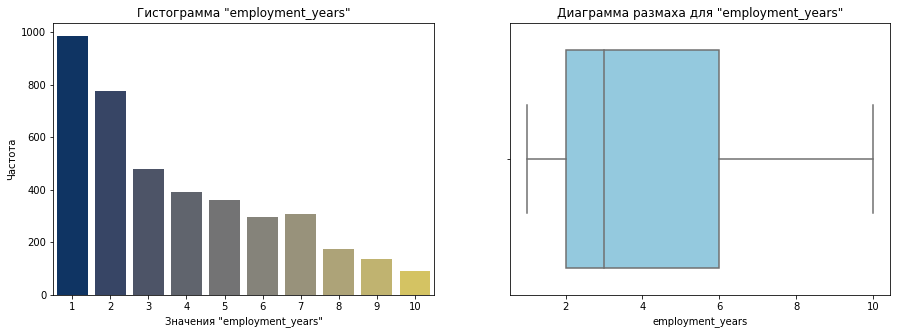

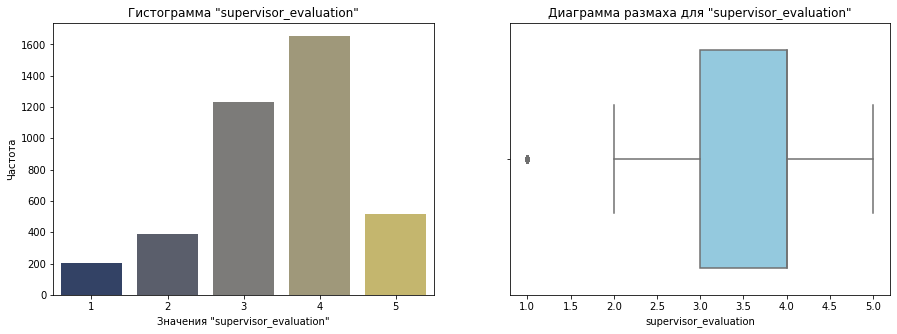

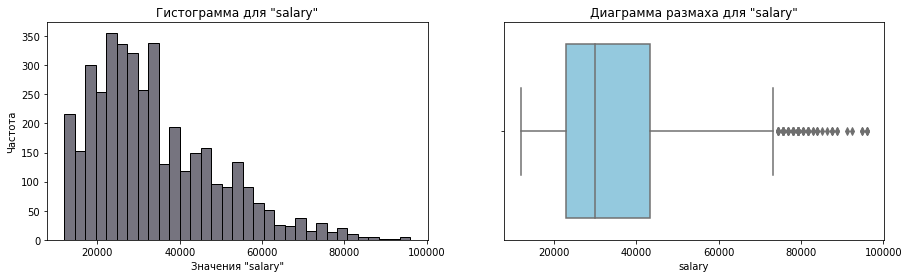

In [62]:
for name in num_col_1:
    disсrete(data_train_quit, name)

continuous(data_train_quit, 'salary')

In [63]:
# посмотрим на графики в разрезе 'quit'

def continuous_1(df, column):
    plt.figure(figsize=(15,5))
    plt.subplot(1, 2, 1)
    plt.title(f'Гистограмма распределения "{column}"')
    sns.histplot(data=df, x=column, hue='quit', palette='cividis', stat='density', common_norm=False)
    plt.xlabel(f'Значение параметра "{column}"')
    plt.ylabel('Плотность вероятности')
    
    plt.subplot(1, 2, 2)
    plt.title(f'Диаграмма размаха для "{column}"')
    sns.boxplot(x='quit', y=column, data=df, palette='cividis');
    plt.ylabel(f'Значение параметра "{column}"')
    
    
def discrette_1(df, column):
    plt.figure(figsize=(15,3))
    plt.subplot(1, 2, 1)
    plt.title(f'Гистограмма распределения "{column}"')
    sns.countplot(data=df, x=column, hue='quit', palette='cividis');
    plt.xlabel(f'Значение параметра {column}')
    plt.ylabel('Частота')
    
    plt.subplot(1, 2, 2)
    plt.title(f'Диаграмма размаха для "{column}"')
    sns.boxplot(x='quit', y=column, data=df, palette='cividis');
    plt.ylabel(f'Значение параметра {column}')

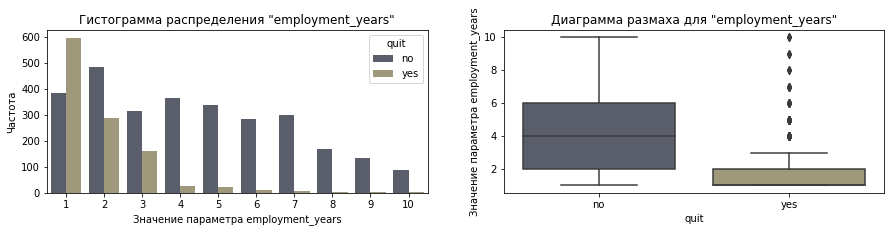

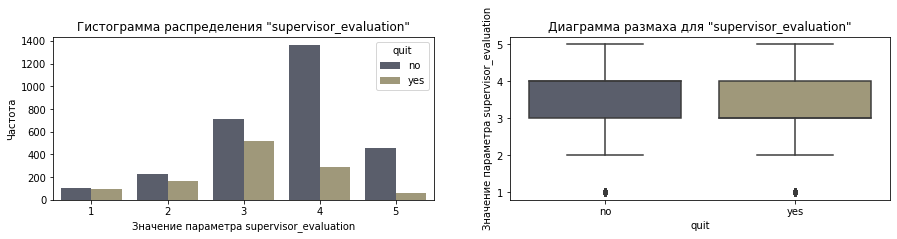

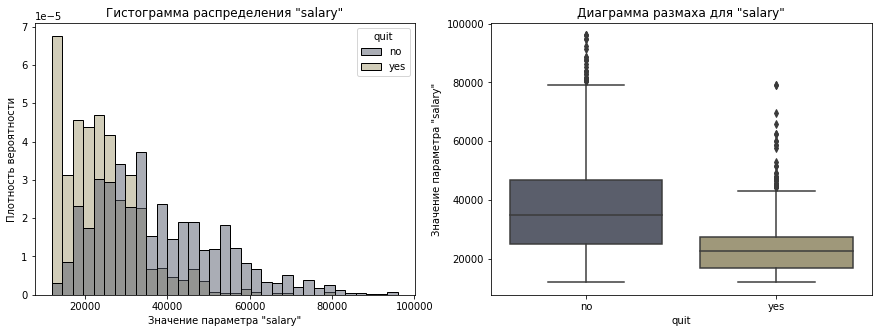

In [64]:
for name in num_col_1:
    discrette_1(data_train_quit, name)

continuous_1(data_train_quit, 'salary')

In [102]:
# теперь посмотрим на категориальные признаки в разрезе 'quit'

def cat_graph_1(df, column):
    plt.figure(figsize=(10,5))
    plt.subplot(1, 2, 1)
    plt.title(f'Признак "{column}"\n quit = yes')
    df=df.groupby([column])['quit'].value_counts(normalize=True)
    yes_df = df.loc[df.index.get_level_values(1) == 'yes']
    plt.pie(x=yes_df,
            startangle=90,
            labeldistance=1.1, 
            wedgeprops={'linewidth':2, 'edgecolor':'white'}, 
            autopct='%1.1f%%',
            labels=df.groupby(column).count().index,
            colors=sns.color_palette('cividis'))
    plt.subplot(1, 2, 2)
    plt.title(f'Признак "{column}"\n quit = no')
    no_df = df.loc[df.index.get_level_values(1) == 'no']
    plt.pie(x=no_df,
            startangle=90,
            labeldistance=1.1, 
            wedgeprops={'linewidth':3, 'edgecolor':'white'}, 
            autopct=lambda p : '{:.2f}%  ({:,.0f}%)'.format(p,p * sum(no_df)), #'%1.1f%%',
            labels=df.groupby(column).count().index, 
            colors=sns.color_palette('cividis'))

In [103]:
cat_col_1 = ['dept', 
           'level', 
           'workload', 
           'last_year_promo', 
           'last_year_violations']

In [104]:
df=data_train_quit.groupby(['level'])['quit'].value_counts(normalize=True)
df.loc[df.index.get_level_values(1) == 'no']

level   quit
junior  no      0.485377
middle  no      0.936246
senior  no      0.952381
Name: quit, dtype: float64

In [105]:
df.loc[df.index.get_level_values(1) == 'yes']

level   quit
junior  yes     0.514623
middle  yes     0.063754
senior  yes     0.047619
Name: quit, dtype: float64

/tmp/ipykernel_95/1301552050.py:9: MatplotlibDeprecationWarning: normalize=None does not normalize if the sum is less than 1 but this behavior is deprecated since 3.3 until two minor releases later. After the deprecation period the default value will be normalize=True. To prevent normalization pass normalize=False 
  plt.pie(x=yes_df,


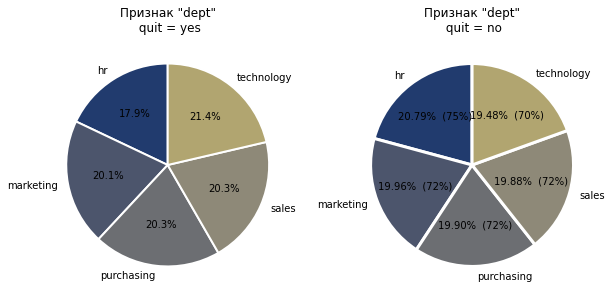

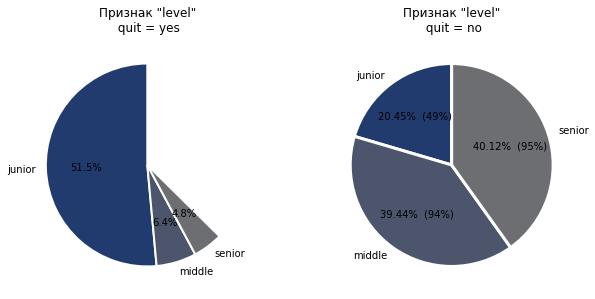

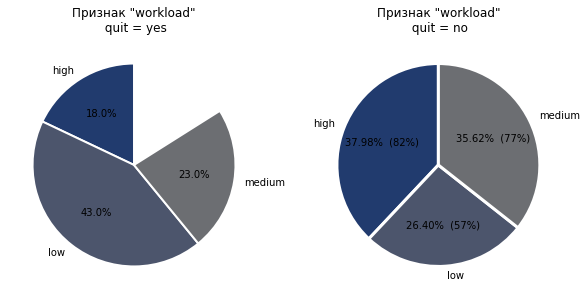

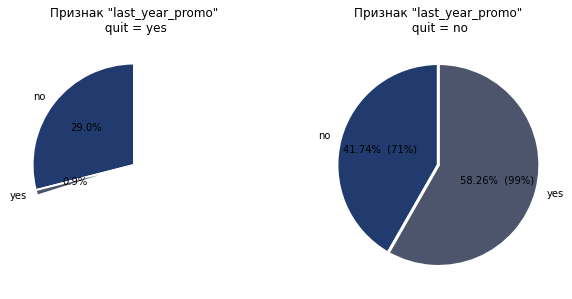

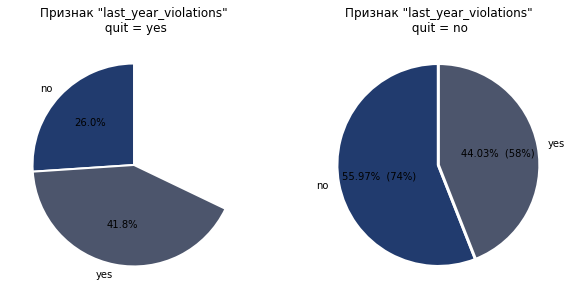

In [106]:
for name in cat_col_1:
    cat_graph_1(data_train_quit, name)

**Портрет уволившегося сотрудника** <br>
* Уровень должности - *Junior*
* Уровень загруженности - *Low*
* Возможно нарушал трудовой жоговор за прошлый год
* Уровень зарплаты ниже *30.000*
* Работает в компании менее *2 лет*

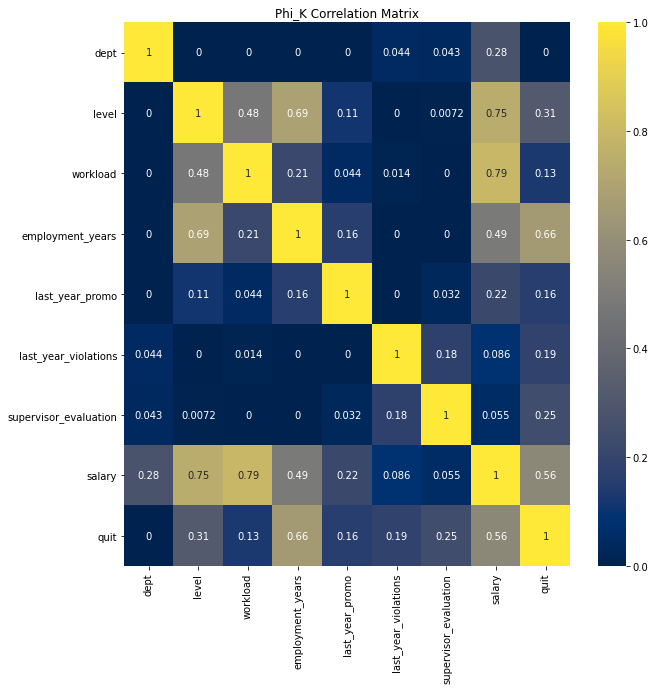

In [70]:
#построим матрицу корреляций
corr_matrix = data_train_quit.drop('id', axis=1).phik_matrix(interval_cols=num_col_2)


#визуализация матрицы корреляции 
plt.figure(figsize=(10, 10))
sns.heatmap(corr_matrix, annot=True, cmap='cividis')
plt.title('Phi_K Correlation Matrix')
plt.show()

признак dept никак не коррелирует с целевым признаком, для дальнейших расчетов уберем его из датафрейма перед обучением модели

## Добавление нового входного признака

In [71]:
data_train_quit.head(10)

,id,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,quit
0,723290,sales,middle,high,2,no,no,4,54000,no
1,814010,sales,junior,medium,2,no,no,4,27600,no
2,155091,purchasing,middle,medium,5,no,no,1,37200,no
3,257132,sales,junior,medium,2,no,yes,3,24000,yes
4,910140,marketing,junior,medium,2,no,no,5,25200,no
5,699916,sales,junior,low,1,no,yes,3,18000,yes
6,417070,technology,middle,medium,8,no,no,2,44400,no
7,165489,sales,middle,low,4,no,no,5,19200,no
8,996399,marketing,middle,low,7,no,no,4,25200,no
9,613206,technology,middle,medium,2,no,no,3,45600,yes


In [72]:
data_train_quit.set_index('id', inplace=True)

In [73]:
#добавление в ттренировочную выборку целевого признака из предыдущей задачи
data_train_quit['job_satisfaction_rate'] = randomized_search.predict(data_train_quit.drop('quit', axis=1 ))

In [74]:
data_train_quit.head(10)

,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,quit,job_satisfaction_rate
id,,,,,,,,,,
723290,sales,middle,high,2,no,no,4,54000,no,0.626667
814010,sales,junior,medium,2,no,no,4,27600,no,0.821905
155091,purchasing,middle,medium,5,no,no,1,37200,no,0.386000
257132,sales,junior,medium,2,no,yes,3,24000,yes,0.350000
910140,marketing,junior,medium,2,no,no,5,25200,no,0.786667
699916,sales,junior,low,1,no,yes,3,18000,yes,0.130000
417070,technology,middle,medium,8,no,no,2,44400,no,0.390000
165489,sales,middle,low,4,no,no,5,19200,no,0.463333
996399,marketing,middle,low,7,no,no,4,25200,no,0.760000


In [75]:
# Добавление в тестовую выборку целевог опризнака из предыдущей задачи
X_test_quit['job_satisfaction_rate'] = randomized_search.predict(X_test_quit)

In [76]:
X_test_quit.head()

,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,job_satisfaction_rate
id,,,,,,,,,
100298,hr,junior,low,2,no,no,4,19200,0.854545
100480,marketing,junior,low,4,no,no,4,16800,0.840000
100503,purchasing,middle,high,5,no,no,4,55200,0.770000
100610,sales,middle,medium,5,no,no,4,43200,0.813333
100692,sales,middle,high,6,no,no,4,48000,0.693333


**Зависимость между job_satisfaction_rate и quit**

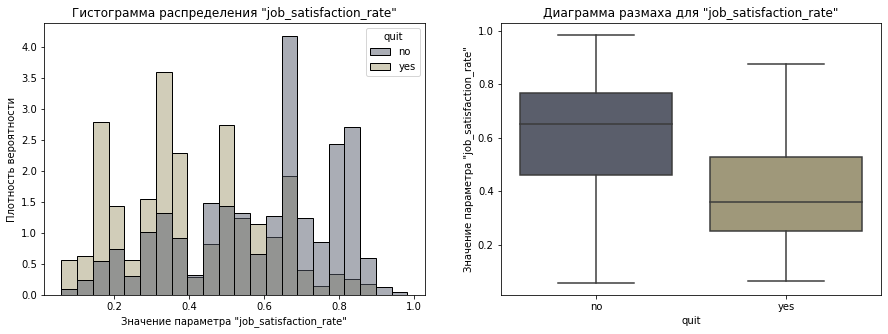

In [77]:
continuous_1(data_train_quit, 'job_satisfaction_rate')

Исходя из графика можно говорить, что job_satisfaction_rate и quit имеют связь. Уровень удовлетворенности ушедших сотрудников ниже уровня удовлетворенности оставшихся.

In [78]:
data_test = X_test_quit.join(y_test_quit)
data_test

,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,job_satisfaction_rate,quit
id,,,,,,,,,,
100298,hr,junior,low,2,no,no,4,19200,0.854545,no
100480,marketing,junior,low,4,no,no,4,16800,0.840000,no
100503,purchasing,middle,high,5,no,no,4,55200,0.770000,no
100610,sales,middle,medium,5,no,no,4,43200,0.813333,no
100692,sales,middle,high,6,no,no,4,48000,0.693333,no
...,...,...,...,...,...,...,...,...,...,...
997290,sales,sinior,medium,7,no,no,4,58800,0.787500,no
998548,marketing,junior,medium,2,no,no,4,32400,0.842000,yes
998762,technology,junior,low,3,no,no,3,22800,0.488889,yes


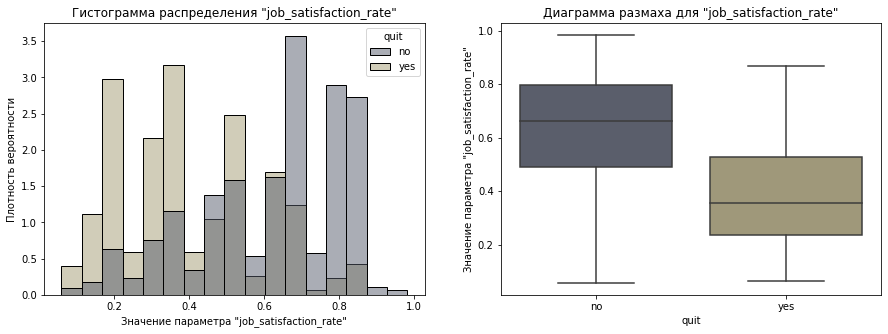

In [79]:
continuous_1(data_test, 'job_satisfaction_rate')

## Подготовка данных

In [80]:
data_train_quit = data_train_quit.drop('dept', axis=1)
X_test_quit = X_test_quit.drop('dept', axis=1)

In [81]:
X_train = data_train_quit.drop('quit', axis=1)
y_train = data_train_quit['quit']

In [82]:
#Закодируем целевой признак
label_encoder = LabelEncoder()

y_train = label_encoder.fit_transform(y_train)
y_test_quit = label_encoder.transform(y_test_quit)

/opt/conda/lib/python3.9/site-packages/sklearn/preprocessing/_label.py:132: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, dtype=self.classes_.dtype, warn=True)


In [83]:
ohe_cols = ['last_year_promo', 'last_year_violations']
ord_cols = ['level', 'workload']
num_cols = ['employment_years', 'supervisor_evaluation', 'salary', 'job_satisfaction_rate']


In [84]:
data_preprocessor_quit = ColumnTransformer(
    [('ord', ord_pipe, ord_cols),
     ('ohe', ohe_pipe, ohe_cols),
     ('num', MinMaxScaler(), num_cols)
    ], 
    remainder='passthrough'
)

In [85]:
pipe_final_quit = Pipeline([
    ('preprocessor', data_preprocessor_quit),
    ('models', DecisionTreeClassifier())
])

In [86]:
param_grid = [

    {
        'models': [LogisticRegression(random_state=RANDOM_STATE)],
        'preprocessor__num': [StandardScaler(), MinMaxScaler(), 'passthrough']     
    },
    # словарь для модели DecisionTreeClassifier()
    {
        'models': [DecisionTreeClassifier(random_state=RANDOM_STATE)],
        'models__max_depth': range(1,15),
        'models__max_features': range(2,20),
        'models__min_samples_split' : range(2,10),
        'models__min_samples_leaf' : range(1,7),
        'preprocessor__num': [StandardScaler(), MinMaxScaler(), 'passthrough']  
    },
    # словарь для модели KNeighborsClassifier()
    {
        'models': [KNeighborsClassifier()],
        'models__n_neighbors': range(5, 20),
        'preprocessor__num': [StandardScaler(), MinMaxScaler(), 'passthrough']   
    }
]


## Обучение модели

In [87]:
randomized_search_quit = RandomizedSearchCV(
    pipe_final_quit, 
    param_grid, 
    cv=10,
    n_iter=25,
    scoring='roc_auc',
    random_state=RANDOM_STATE,
    n_jobs=-1
)

In [88]:
randomized_search_quit.fit(X_train, y_train)

RandomizedSearchCV(cv=10,
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(remainder='passthrough',
                                                                transformers=[('ord',
                                                                               Pipeline(steps=[('simple_imputer_ord_before',
                                                                                                SimpleImputer(strategy='most_frequent')),
                                                                                               ('simple_imputer_ord_before_1',
                                                                                                SimpleImputer(missing_values=' ',
                                                                                                              strategy='most_frequent')),
                                                                                               ('ord',
                                                                                                OrdinalEncoder(categories=[['junior',...
                                         'models__max_features': range(2, 20),
                                         'models__min_samples_leaf': range(1, 7),
                                         'models__min_samples_split': range(2, 10),
                                         'preprocessor__num': [StandardScaler(),
                                                               MinMaxScaler(),
                                                               'passthrough']},
                                        {'models': [KNeighborsClassifier()],
                                         'models__n_neighbors': range(5, 20),
                                         'preprocessor__num': [StandardScaler(),
                                                               MinMaxScaler(),
                                                               'passthrough']}],
                   random_state=42, scoring='roc_auc')

In [89]:
results = pd.DataFrame(randomized_search_quit.cv_results_)
results.sort_values(by='rank_test_score')

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_preprocessor__num,param_models__min_samples_split,param_models__min_samples_leaf,param_models__max_features,param_models__max_depth,param_models,...,split3_test_score,split4_test_score,split5_test_score,split6_test_score,split7_test_score,split8_test_score,split9_test_score,mean_test_score,std_test_score,rank_test_score
0,0.026245,0.001855,0.010300,0.001519,StandardScaler(),2,5,3,7,DecisionTreeClassifier(random_state=42),...,0.940427,0.925596,0.931948,0.915266,0.932688,0.932071,0.956955,0.931310,0.011099,1
2,0.026653,0.000992,0.010083,0.000641,MinMaxScaler(),2,3,8,5,DecisionTreeClassifier(random_state=42),...,0.933551,0.915282,0.935247,0.925550,0.934214,0.923145,0.959221,0.929391,0.011929,2
4,0.024593,0.001503,0.008860,0.000756,passthrough,9,6,10,7,DecisionTreeClassifier(random_state=42),...,0.941954,0.891369,0.950017,0.893790,0.935617,0.928032,0.958882,0.925797,0.021047,3
11,0.027205,0.001859,0.009463,0.000355,StandardScaler(),9,6,15,7,DecisionTreeClassifier(random_state=42),...,0.941954,0.891369,0.950017,0.893790,0.935617,0.928032,0.958882,0.925797,0.021047,3
6,0.025641,0.000223,0.009552,0.000336,StandardScaler(),6,2,5,7,DecisionTreeClassifier(random_state=42),...,0.946193,0.885495,0.926290,0.921557,0.935802,0.948044,0.967331,0.925672,0.022984,5
15,0.029049,0.001537,0.010026,0.000691,StandardScaler(),9,5,12,11,DecisionTreeClassifier(random_state=42),...,0.934260,0.910471,0.939687,0.908853,0.937036,0.912969,0.960146,0.925289,0.015874,6
18,0.026028,0.003343,0.009511,0.001271,passthrough,8,6,3,8,DecisionTreeClassifier(random_state=42),...,0.923730,0.913555,0.927508,0.923222,0.931177,0.923314,0.954118,0.924459,0.011425,7
17,0.028321,0.000445,0.010079,0.000216,StandardScaler(),3,4,7,8,DecisionTreeClassifier(random_state=42),...,0.954072,0.894329,0.936265,0.907018,0.943989,0.914912,0.955166,0.923547,0.020716,8
5,0.024079,0.000779,0.008136,0.000243,passthrough,9,3,10,9,DecisionTreeClassifier(random_state=42),...,0.936419,0.896164,0.941075,0.899047,0.938007,0.909068,0.954642,0.922298,0.018329,9
21,0.026290,0.002830,0.008969,0.000725,passthrough,5,5,8,8,DecisionTreeClassifier(random_state=42),...,0.917656,0.892032,0.939980,0.906771,0.930159,0.918797,0.957695,0.921423,0.017085,10


In [90]:

print('Метрика  ROC-AUC лучшей модели на кросс-валидационной выборке:\n', round(randomized_search_quit.best_score_, 5)) 
print('Лучшая модель и её параметры:\n\n', randomized_search_quit.best_params_) 

Метрика  ROC-AUC лучшей модели на кросс-валидационной выборке:
 0.93131
Лучшая модель и её параметры:

 {'preprocessor__num': StandardScaler(), 'models__min_samples_split': 2, 'models__min_samples_leaf': 5, 'models__max_features': 3, 'models__max_depth': 7, 'models': DecisionTreeClassifier(random_state=42)}


In [91]:
y_test_proba = randomized_search_quit.predict_proba(X_test_quit)
print(f'Метрика ROC-AUC на тестовой выборке: {round(roc_auc_score(y_test_quit, y_test_proba[:,1]), 5)}')

Метрика ROC-AUC на тестовой выборке: 0.91861


Метрика  ROC-AUC лучшей модели на кросс-валидационной выборке - 0.93131, на тестовой -  0.91861. Это удовлетворяет поставленному условию ROC-AUC не ниже 0.91

## Общий вывод

Перед нами стояла задача помочь компании «Работа с заботой»  оптимизировать управление персоналом на основе предоставленных данных.<br>
Компания предоставила данные с характеристиками сотрудников компании. Среди них — уровень удовлетворённости сотрудника работой в компании.<br><br>
Решить необходимо было следующие задачи:<br>
1. Построить модель, которая сможет предсказать уровень удовлетворённости сотрудника на основе данных заказчика. 
2. Построить модель, которая сможет на основе данных заказчика предсказать то, что сотрудник уволится из компании. <br>
<br>
**Для решения первой задачи:**
* Изучили предоставленные данных
* Провели предобработку данных, выявили отсутствие дубликатов в данных, исправили опечатки, обнаружили пропуски, которые были далее заполнены в пайплайне
* Провели исследовательский анализ. Визуализировали количественные и категориальные параметры, построили матрицу корреляций
* Выполнили подготовку данных. Закодировали и масштабировали признаки. Сделали пайплайны, в них же заполнили пропуски в данных. Использовали для кодирования 2 кодировщика OneHotEncoder и OrdinalEncoder
* Обучили модели и выбрали лучшую модель с помощью RandomizedSearch. Лучшую модель выбирали по метрике SMAPE. Лучшей моделью оказалась DecisionTreeRegressor с метрикой SMAPE на кросс-валидационной выборке 14.72, на тестовой выборке 13.48, что удовлетворяет условию поставленной задачи SMAPE <15<br><br>
 **Для решения второй задачи:**
* Изучили предосталвенные данные, тестовая выборка не отличается от первой задачи.
* Провели предобработку данных, выявили отсутствие дубликатов в данных, исправили опечатки, обнаружили пропуски, которые были далее заполнены в пайплайне
* Провели исследовательский анализ. Визуализировали количественные и категориальные параметры в разрезе целевого признака, построили матрицу корреляций. После построения матрицы корреляций обнарукжено отсутствие корреляции целевого признака в признаком 'dept', его использовать для обучения модели не будем.
* Добавили признак job_satisfaction_rate на основе предсказаний модели из первой задачи.
* Визуализировали связь между целевым признаком второй задачи и job_satisfatction_rate.
* Подготовили данные. Закодировали и масстабировали признаки, заполнили пропуски в пайплайне. Использовали два кодировщика OneHotEncoder и OrdinalEncoder.
* Обучили модели и выбрали лучшую с помощью RandomizedSearch. Для обучения были использованы DecisionTreeClassifier, LogisiticRegression и KNeighborsClassifier. Лучшей моделью стала DecisionTreeClassifier c метрикой  ROC-AUCна кросс-валидационной выборке - 0.93131, на тестовой -  0.91861. Это удовлетворяет поставленному условию ROC-AUC не ниже 0.91